In [ ]:
# 프로젝트 1

In [ ]:
## sklearn dt 가져오기

In [1]:
from sklearn.datasets import load_diabetes

In [ ]:
## 입력 데이터 x와, 목표값 y를 설정

In [2]:
data = load_diabetes()
df_X = data.data
df_y = data.target

In [ ]:
##모델에 x값을 np array로 변경

In [3]:
import numpy as np

In [4]:
X = np.array(df_X)

In [5]:
print(type(X), X.dtype)

<class 'numpy.ndarray'> float64


In [ ]:
##모델에 y값을 np array로 변경

In [6]:
y = np.array(df_y)

In [7]:
print(type(y), y.dtype)

<class 'numpy.ndarray'> float64


In [ ]:
## x와 y를 각각 트레인 데이터와 테스트 데이터로 분리하기
트레인 데이터: for 모델 학습
테스트 데이터: for 평가(테스트를 위함)

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
## 모델 준비 후 데이터에 맞게 가중치 w,b 설정
(모델이 학습을 시작하도록)

In [9]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


In [10]:
W = np.random.rand(X_train.shape[1])
b = np.random.rand()

In [11]:
print(len(W))

10


In [17]:
def model(X, W, b):
    predictions = X.dot(W) + b
    return predictions

In [12]:
def MSE(a, b):
    mse = ((a - b) ** 2).mean()  # 두 값의 차이의 제곱의 평균
    return mse

In [13]:
def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L

In [14]:
def gradient(X, W, b, y):
    N = len(y)

    y_pred = model(X, W, b)

    dW = 1/N * 2 * X.T.dot(y_pred - y)

    db = 2 * (y_pred - y).mean()
    return dW, db

In [15]:
LEARNING_RATE = 0.001

In [25]:
np.random.seed(42)
W = np.random.rand(X_train.shape[1])
b = np.random.rand()
LEARNING_RATE = 0.05

In [26]:
losses = []

In [27]:
for i in range(1, 10000):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)

In [28]:
if i % 1000 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))

In [29]:
prediction = model(X_test, W, b)
mse = loss(X_test, W, b, y_test)
mse

np.float64(2866.925629584937)

In [ ]:
# MSE(Mean Squared Error)값 3000 이하 달성
MSE 값: 모델의 예측값과 실제값이 평균적으로 얼마나 차이가 나는지를 나타냄

In [30]:
import matplotlib.pyplot as plt

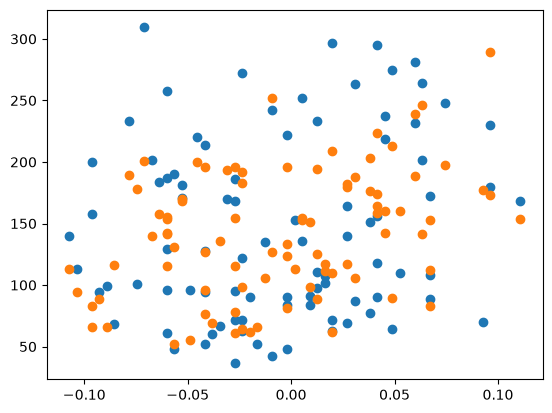

In [31]:
plt.scatter(X_test[:, 0], y_test)
plt.scatter(X_test[:, 0], prediction)
plt.show()

In [23]:
#
주황점 모델이 예측한 값이 동일 선상에서 그린 것처럼 일직선을 이루고 있다. 
이는 특성이 결과에 미치는 영향 가중치를 잘 못 찾아서, 평균 근처의 값에 의존해서 찍고 있는 상태이다.
25번 셀의 LEARNING_RATE를 0.05로 조정하고, 반복 횟수를 10000으로 늘림

In [ ]:
#
모델이 예측한 값 결과 주황점이 고르게 퍼지게 되었다. 

In [ ]:
# 프로젝트 2 날씨 좋은 월요일 자전거 타는 사람은 몇 명?

In [35]:
import gdown
import pandas as pd

ModuleNotFoundError: No module named 'gdown'

In [36]:
!pip install gdown

In [37]:
import gdown
import pandas as pd

In [38]:
gdown.download('https://drive.google.com/uc?id=1KSQVnefQtRarL-6w5vdd4368hebk3IYG', 'train.csv', quiet=False)
train = pd.read_csv("train.csv") 
train.info()

Downloading...
From: https://drive.google.com/uc?id=1KSQVnefQtRarL-6w5vdd4368hebk3IYG
To: /Users/sooah/train.csv
100%|███████████████████████████████████████| 648k/648k [00:00<00:00, 3.48MB/s]


<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1.2 MB


In [39]:
train['datetime'] = pd.to_datetime(train['datetime'])
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second

train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[us]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  minute      10886 non-null  int32

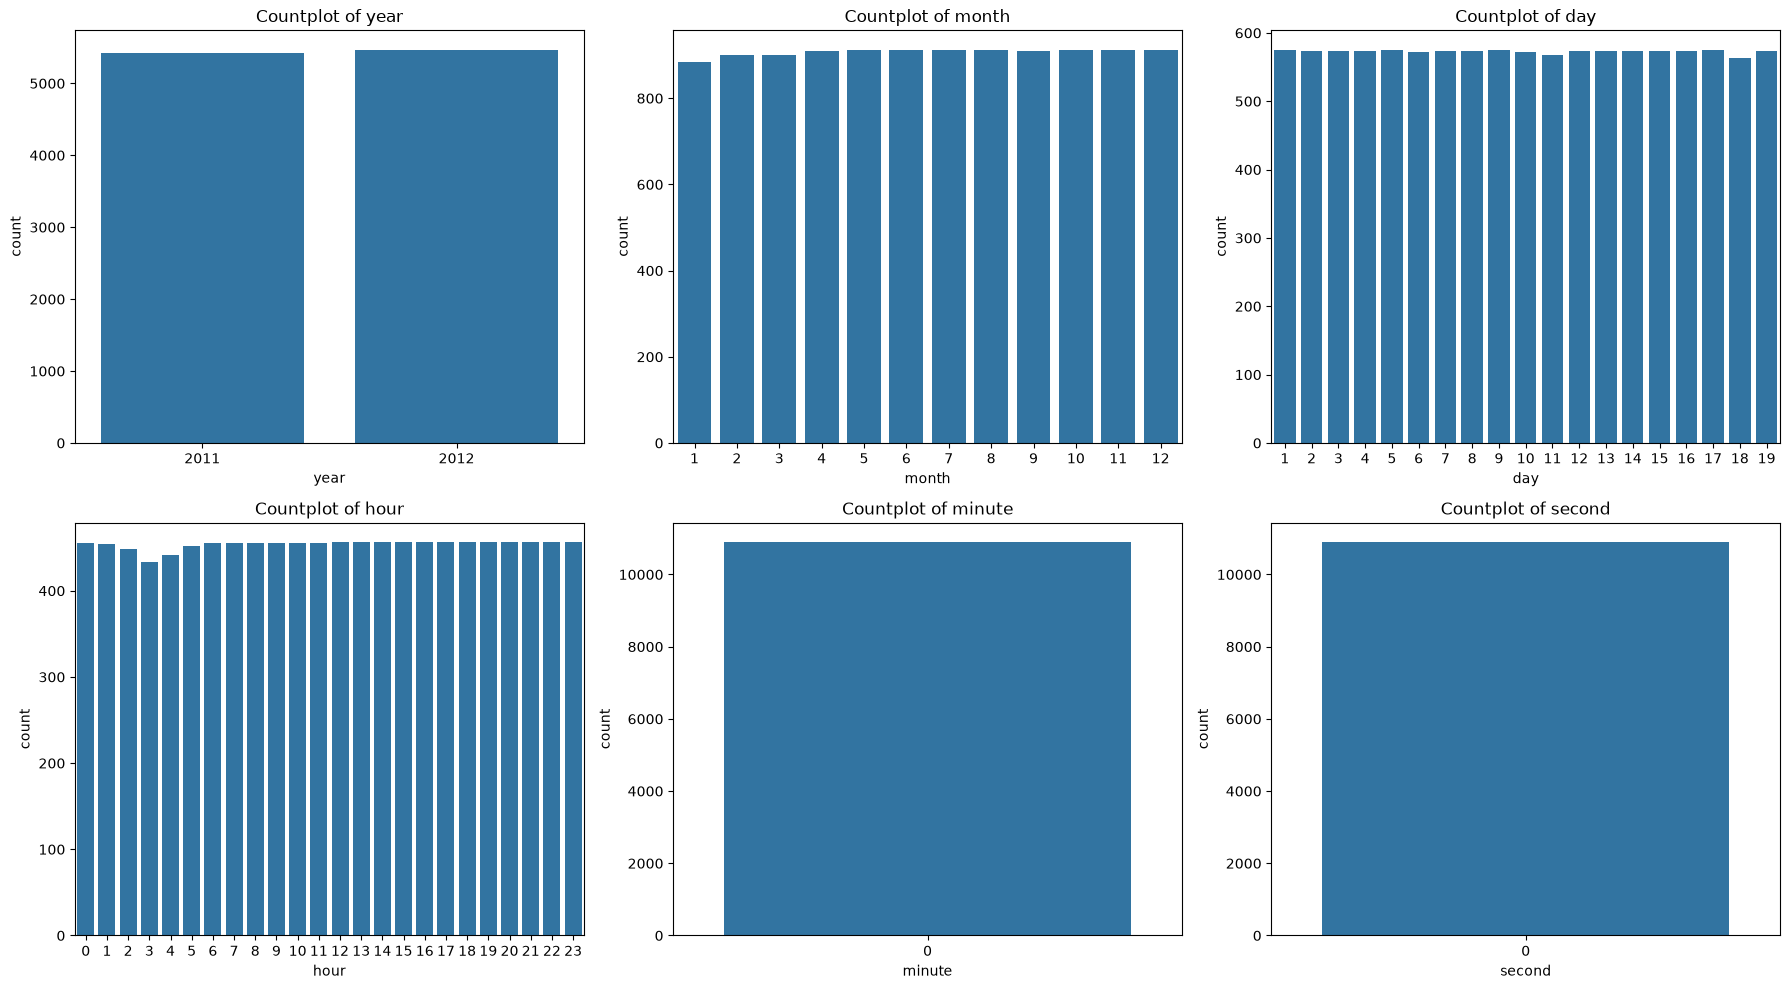

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
cols = ['year', 'month', 'day', 'hour', 'minute', 'second']
for ax, col in zip(axs.flatten(), cols):
    sns.countplot(x=col, data=train, ax=ax)
    ax.set_title(f'Countplot of {col}')
plt.tight_layout()
plt.show()

In [41]:
features = ['year', 'month', 'day', 'hour', 'temp', 'humidity', 'windspeed']
X = train[features]
y = train['count']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[82.31, 7.71, 0.23,..., 6.52,-2.1 , 0.29]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['year','month','day',...,'temp','humidity','windspeed']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.655e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


In [43]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 19961.901814435474
RMSE: 141.28659460272752


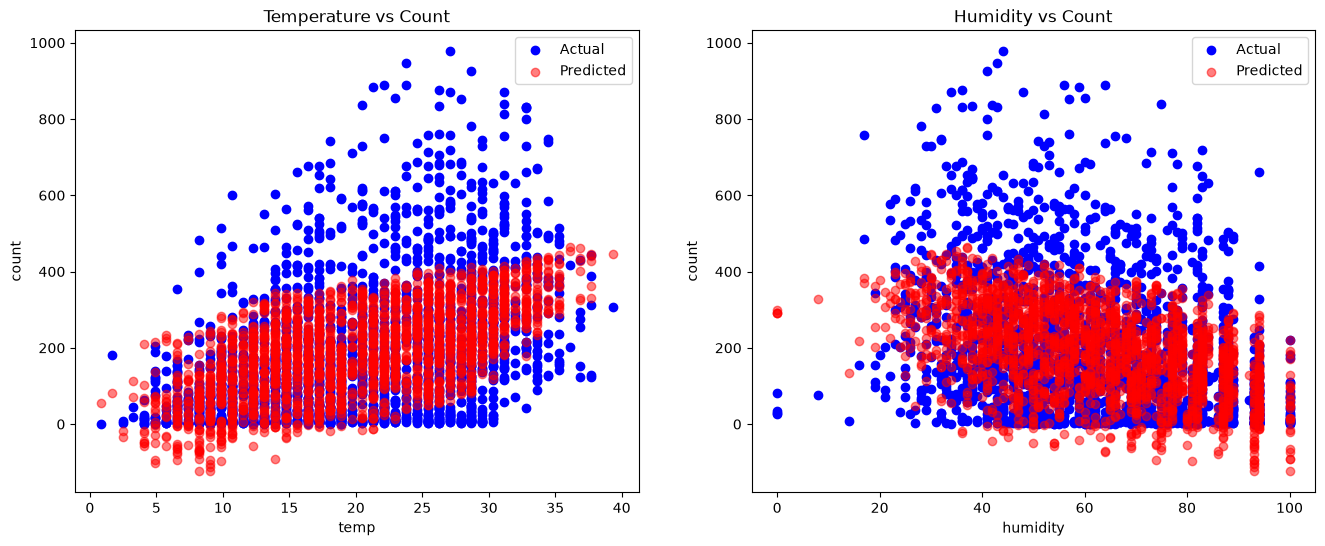

In [44]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# temp vs count 시각화
axs[0].scatter(X_test['temp'], y_test, color='blue', label='Actual')
axs[0].scatter(X_test['temp'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[0].set_xlabel('temp')
axs[0].set_ylabel('count')
axs[0].set_title('Temperature vs Count')
axs[0].legend()

# humidity vs count 시각화
axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual')
axs[1].scatter(X_test['humidity'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()